In [72]:
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd /content/rainfall_kf
!git pull origin main
!pip uninstall -y rainfall_kf
!pip install -e .

/content/rainfall_kf
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 2), reused 10 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 1.52 MiB | 6.46 MiB/s, done.
From https://github.com/Felix-Schwer/rainfall_kf
 * branch            main       -> FETCH_HEAD
   460188d..5e42b1c  main       -> origin/main
Updating 460188d..5e42b1c
Fast-forward
 data/gpm_sjv_subset.nc                             |  Bin 5055095 -> 0 bytes
 data/openet_sjv_subset.nc                          |  Bin 44717172 -> 0 bytes
 .../HUC8 - CONUS All.cpg}                          |    0
 data/shapefiles/HUC8 - CONUS All.dbf               |  Bin 0 -> 8581 bytes
 .../HUC8 - CONUS All.prj}                          |    0
 data/shapefiles/HUC8 - CONUS All.qmd               |  113 ++
 data/shapefiles/HUC8 - CONUS All.shp               |  Bin 0 -> 2085500 bytes
 data/shapefiles/HUC8 - CONUS All.shx     

In [79]:
import xarray as xr
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
da = xr.open_dataset('/content/rainfall_kf/data/gpm_sjv_huc8_subset.nc')

<xarray.Dataset> Size: 27MB
Dimensions:        (time: 7671, lat: 26, lon: 34)
Coordinates:
  * time           (time) datetime64[ns] 61kB 2000-01-01 ... 2020-12-31
  * lat            (lat) float32 104B 36.35 36.45 36.55 ... 38.65 38.75 38.85
  * lon            (lon) float32 136B -121.9 -121.8 -121.8 ... -118.8 -118.7
Data variables:
    precipitation  (time, lat, lon) float32 27MB ...
    precip_mean    (time) float32 31kB ...
    crs            int32 4B ...
Attributes:
    title:        GPM IMERG Late Run — San Joaquin Valley subset
    source:       NASA GPM IMERG Late Run V06
    shapefile:    C:\Users\mwwan\Documents\Research_Data\sjvw_boundaries\smal...
    date_range:   2000-01-01 to 2020-12-31
    created:      2026-05-20T18:43:04Z
    Conventions:  CF-1.8

In [116]:
lon2d, lat2d = np.meshgrid(da.lon, da.lat)
points = gpd.GeoSeries(gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()), crs="EPSG:4326")

basins_df = gpd.read_file('/content/rainfall_kf/data/shapefiles/HUC8 - CONUS All.shp')

basin_ids = basins_df['HUC8']

precip_means = []
for index, basin in basins_df.iterrows():
    basin = gpd.GeoDataFrame([basin], geometry='geometry', crs="EPSG:4326")
    inside = basin.union_all().contains(points).to_numpy().reshape(lat2d.shape)
    precip_means.append(da.precipitation.where(inside).mean(dim=['lon', 'lat']))

mean_ds = xr.concat(precip_means, dim=xr.DataArray(basin_ids, dims='basin', name='basin_HUC8'))
# create a dataset from the basin-mean DataArray and attach per-basin metadata as basin-coordinate variables
ds_precip = xr.Dataset({"precip_basin_mean": mean_ds})

# ensure basins are ordered to match the 'basin' coordinate in mean_ds
basins_by_huc = basins_df.set_index(basin_ids)
basins_ordered = basins_by_huc.loc[basin_ids]

# attach non-geometry metadata columns as basin coords
for col in basins_ordered.columns:
    if col == "geometry":
        continue
    ds_precip = ds_precip.assign_coords({f"basin_{col}": ("basin", basins_ordered[col].to_numpy())})

# attach geometry as WKT strings (safer for xarray coords)
ds_precip = ds_precip.assign_coords(
    {"basin_geometry_wkt": ("basin", basins_ordered.geometry.apply(lambda g: g.wkt).to_numpy())}
)

ds_precip

<xarray.Dataset> Size: 462kB
Dimensions:             (time: 7671, basin: 13)
Coordinates: (12/17)
  * time                (time) datetime64[ns] 61kB 2000-01-01 ... 2020-12-31
  * basin               (basin) object 104B '18040001' '18040002' ... '18040013'
    basin_TNMID         (basin) object 104B '{4C042998-AA2A-4451-9A93-A76BDF8...
    basin_METASOURCE    (basin) object 104B None None None ... None None None
    basin_SOURCEDATA    (basin) object 104B None None None ... None None None
    basin_SOURCEORIG    (basin) object 104B None None None ... None None None
    ...                  ...
    basin_STATES        (basin) object 104B 'CA' 'CA' 'CA' ... 'CA' 'CA' 'CA'
    basin_HUC8          (basin) object 104B '18040001' '18040002' ... '18040013'
    basin_NAME          (basin) object 104B 'Middle San Joaquin-Lower Chowchi...
    basin_Shape_Leng    (basin) float64 104B 8.651 3.287 5.323 ... 5.757 3.688
    basin_Shape_Area    (basin) float64 104B 0.9256 0.242 ... 0.3381 0.2541
    basin_geometry_wkt  (basin) object 104B 'POLYGON ((-119.69071505599993 37...
Data variables:
    precip_basin_mean   (basin, time) float32 399kB 0.02222 0.1606 ... 0.9654

In [113]:
mean_ds.basin

<xarray.DataArray 'basin' (basin: 13)> Size: 104B
array([18040001, 18040002, 18040003, 18040006, 18040007, 18040008, 18040009,
       18040011, 18040014, 18040051, 18040010, 18040012, 18040013])
Coordinates:
  * basin    (basin) int64 104B 18040001 18040002 18040003 ... 18040012 18040013

In [ ]:

inside = merceddf.geometry.union_all().contains(points).to_numpy().reshape(lat2d.shape)

da.precipitation.where(inside).mean(dim=['lon', 'lat'])

<xarray.DataArray 'precipitation' (time: 7671)> Size: 31kB
array([0.0125    , 0.19694442, 0.01208333, ..., 0.00291667, 0.08277778,
       0.36166665], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-31
Attributes:
    units:         mm/day
    long_name:     daily precipitation rate (basin-masked)
    grid_mapping:  crs

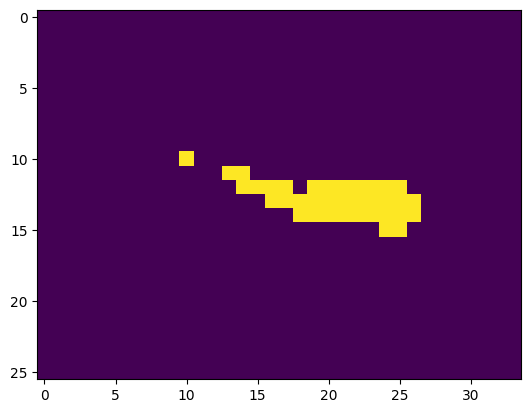

In [ ]:
plt.imshow()

/tmp/ipykernel_25712/1015953006.py:1: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  plt.imshow(points.contains(merceddf.geometry).to_numpy().reshape(lat2d.shape))


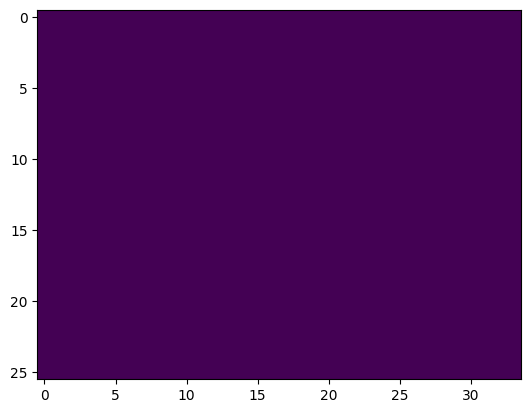

In [50]:
plt.imshow(points.contains(merceddf.geometry).to_numpy().reshape(lat2d.shape))

<Axes: >

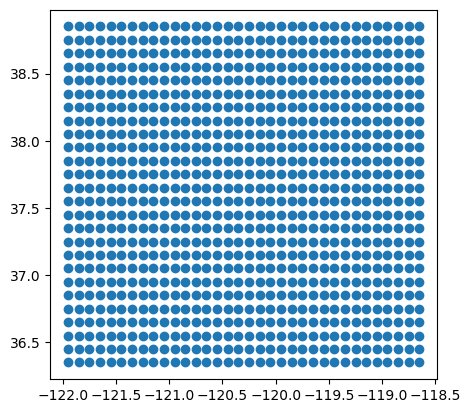

In [37]:
points.plot()

In [35]:
#da.sel(time='2010-01-01').precipitation.plot()
np.all(np.isnan(masked.sel(time='2010-01-01').data))

np.True_

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path


def pick_data_var(ds):
    """Pick a likely gridded time-varying variable from a dataset."""
    candidates = []
    for name, da_var in ds.data_vars.items():
        dims_lower = {d.lower() for d in da_var.dims}
        if any(t in dims_lower for t in ["time", "valid_time"]):
            if len(da_var.dims) >= 3:
                candidates.append(name)
    if not candidates:
        candidates = list(ds.data_vars)
    if not candidates:
        raise ValueError("No data variables found in dataset")
    return candidates[0]


def find_coord_names(ds):
    lat_names = ["lat", "latitude", "y"]
    lon_names = ["lon", "longitude", "x"]

    lat_name = next((c for c in lat_names if c in ds.coords), None)
    lon_name = next((c for c in lon_names if c in ds.coords), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not find lat/lon coordinates in dataset. Found coords: {list(ds.coords)}"
        )
    return lat_name, lon_name


def gridcell_areas_m2(lat_1d, lon_1d):
    """Approximate geodesic cell areas for a regular lat/lon grid."""
    R = 6_371_000.0
    lat_rad = np.deg2rad(lat_1d)
    lon_rad = np.deg2rad(lon_1d)

    dlat = np.gradient(lat_rad)
    dlon = np.gradient(lon_rad)

    area = (R ** 2) * np.cos(lat_rad)[:, None] * dlat[:, None] * dlon[None, :]
    return np.abs(area)


def basin_timeseries(ds, basin_gdf, var_name=None):
    lat_name, lon_name = find_coord_names(ds)
    if var_name is None:
        var_name = pick_data_var(ds)

    da_var = ds[var_name]

    # Ensure dataset has standard dimension order: time, lat, lon
    time_name = "time" if "time" in da_var.dims else "valid_time"
    da_var = da_var.transpose(time_name, lat_name, lon_name)

    # Project basin geometry into geographic CRS for point-in-polygon test
    if basin_gdf.crs is None:
        basin_geo = basin_gdf.set_crs("EPSG:4326")
    else:
        basin_geo = basin_gdf.to_crs("EPSG:4326")

    basin_geom = basin_geo.union_all()

    lat = ds[lat_name].values
    lon = ds[lon_name].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    points = gpd.GeoSeries(
        gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()), crs="EPSG:4326"
    )
    inside = points.intersects(basin_geom).to_numpy().reshape(lat2d.shape)

    # Mask outside basin
    masked = da_var.where(inside)

    # Area-weighted basin mean (e.g., basin-average rainfall depth)
    area = gridcell_areas_m2(lat, lon)
    area_in = np.where(inside, area, np.nan)

    weights_da = xr.DataArray(
        area_in,
        coords={lat_name: ds[lat_name], lon_name: ds[lon_name]},
        dims=(lat_name, lon_name),
    )

    basin_mean = (masked * weights_da).sum(dim=(lat_name, lon_name), skipna=True) / weights_da.sum(
        dim=(lat_name, lon_name), skipna=True
    )

    # Basin-integrated volume if variable is depth in mm per timestep
    # (mm -> m, then multiply by cell area)
    basin_volume_m3 = ((masked / 1000.0) * weights_da).sum(
        dim=(lat_name, lon_name), skipna=True
    )

    out = pd.DataFrame(
        {
            "time": ds[time_name].values,
            f"{var_name}_basin_mean": basin_mean.values,
            f"{var_name}_basin_volume_m3": basin_volume_m3.values,
        }
    )
    return out, var_name


# ---- Paths: works in both local VS Code and Colab-style folder layouts ----
root = Path.cwd()
if (root / "data").exists():
    data_dir = root / "data"
elif (root / "rainfall_kf" / "data").exists():
    data_dir = root / "rainfall_kf" / "data"
else:
    raise FileNotFoundError("Could not find data directory from current working directory")

nc_path = data_dir / "gpm_sjv_huc8_subset.nc"
shp_path = data_dir / "HUC8 - CONUS Upper Merced.shp"

# Load data
ds = xr.open_dataset(nc_path)
basin = gpd.read_file(shp_path)

# Compute basin-bucket scalar time series
basin_df, used_var = basin_timeseries(ds, basin)
print(f"Using variable: {used_var}")
basin_df.head()
